***RAYMER GEOMETRY SIZING***

In [1]:
# ============================================================
# TBM-X — 06 RAYMER GEOMETRY SIZING
# ============================================================
#
# Amaç:
#
#   MTOW
#      ↓
#   Wing Loading
#      ↓
#   Wing Area (S)
#      ↓
#   Aspect Ratio (AR)
#      ↓
#   Span (b)
#      ↓
#   Mean Aerodynamic Chord (c̄)
#      ↓
#   Preliminary Wing Geometry
#
# Bu notebook Raymer-based conceptual geometry sizing
# yaklaşımını TBM-X physics modeline bağlar.
#
# ÖNEMLİ:
# Bu aşamadaki geometri "preliminary conceptual design"dır.
#
# Benchmark verileri:
#   - başlangıç tahmini
#   - sanity check
#   - validation
#
# olarak kullanılacaktır.
#
# Benchmark'a zorla uydurma yapılmayacaktır..
#
# ============================================================

**LIBRARIES**

In [2]:
# ============================================================
# LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries loaded successfully.")

Libraries loaded successfully.


**WORKING DIRECTORY**

In [3]:
# ============================================================
# WORKING DIRECTORY
# ============================================================

current_dir = Path.cwd()

print("Current working directory:")
print(current_dir)

Current working directory:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering


**DESIGN REQUIREMENTS**

In [4]:
# ============================================================
# TBM-X DESIGN REQUIREMENTS
# ============================================================

requirements = {
    "aircraft_category": "Single Engine Turboprop",

    "crew": 1,
    "passengers": 5,

    "range_km": 3000,

    "cruise_speed_kt": 300,
    "cruise_altitude_ft": 25000,
    "service_ceiling_ft": 31000,

    "initial_mtow_kg": 3400,

    # Initial conceptual requirement
    "stall_speed_landing_kt": 65,
}

requirements

{'aircraft_category': 'Single Engine Turboprop',
 'crew': 1,
 'passengers': 5,
 'range_km': 3000,
 'cruise_speed_kt': 300,
 'cruise_altitude_ft': 25000,
 'service_ceiling_ft': 31000,
 'initial_mtow_kg': 3400,
 'stall_speed_landing_kt': 65}

**UNIT CONVERSIONS**

In [5]:
# ============================================================
# UNIT CONVERSIONS
# ============================================================

FT_TO_M = 0.3048
KT_TO_MS = 0.514444
KG_TO_LB = 2.20462262
LB_TO_KG = 1 / KG_TO_LB

g = 9.80665

stall_speed_landing_ms = (
    requirements["stall_speed_landing_kt"]
    * KT_TO_MS
)

service_ceiling_m = (
    requirements["service_ceiling_ft"]
    * FT_TO_M
)

print(
    f"Stall speed: {stall_speed_landing_ms:.2f} m/s"
)

print(
    f"Service ceiling: {service_ceiling_m:.1f} m"
)

Stall speed: 33.44 m/s
Service ceiling: 9448.8 m


**LOAD RESULTS FROM NOTEBOOK 05**

In [6]:
# ============================================================
# LOAD RESULTS FROM NOTEBOOK 05
# ============================================================
#
# İlk geliştirme aşamasında 05 notebook'un sonucunu
# burada manuel olarak kullanıyoruz.
#
# Daha sonra bunları ortak Python module / pipeline
# üzerinden otomatik bağlayacağız.
# ============================================================

MTOW_kg = 1689.0

print(f"Input MTOW = {MTOW_kg:.2f} kg")

Input MTOW = 1689.00 kg


**WING LOADING**

In [7]:
# ============================================================
# WING LOADING
# ============================================================
#
# Wing loading:
#
#       W/S
#
# where:
#       W = aircraft weight
#       S = wing reference area
#
# SI form:
#
#       N/m²
#
# Mass-based form:
#
#       kg/m²
#
# For conceptual sizing we will keep both.
# ============================================================

MTOW_N = MTOW_kg * g

print(f"MTOW = {MTOW_N:.1f} N")

MTOW = 16563.4 N


**INITIAL WING LOADING**

In [8]:
# ============================================================
# INITIAL WING LOADING
# ============================================================

# Benchmark-informed initial value.
# This is NOT the final TBM-X wing loading.

initial_wing_area_m2 = 18.0

initial_wing_loading_kg_m2 = (
    MTOW_kg / initial_wing_area_m2
)

initial_wing_loading_N_m2 = (
    MTOW_N / initial_wing_area_m2
)

print(
    f"Initial wing loading = "
    f"{initial_wing_loading_kg_m2:.1f} kg/m²"
)

print(
    f"Initial wing loading = "
    f"{initial_wing_loading_N_m2:.1f} N/m²"
)

Initial wing loading = 93.8 kg/m²
Initial wing loading = 920.2 N/m²


**STALL SPEED CONSTRAINT**

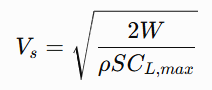

So;

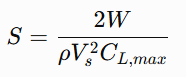

**STALL CONSTRAINT**

In [9]:
# ============================================================
# STALL CONSTRAINT
# ============================================================

stall_constraint = {
    "stall_speed_kt": requirements[
        "stall_speed_landing_kt"
    ],

    # Initial engineering assumption.
    # Later this should come from aerodynamic configuration.
    "CLmax_landing": 1.8,

    # Sea-level ISA density
    "rho_kg_m3": 1.225,

    "origin": "Engineering Assumption",
}

stall_constraint

{'stall_speed_kt': 65,
 'CLmax_landing': 1.8,
 'rho_kg_m3': 1.225,
 'origin': 'Engineering Assumption'}

**CALCULATE WING AREA FROM STALL SPEED CONSTRAINT**

In [10]:
# ============================================================
# WING AREA FROM STALL SPEED CONSTRAINT
# ============================================================

rho_sl = stall_constraint["rho_kg_m3"]
CLmax_landing = stall_constraint["CLmax_landing"]
Vs = stall_speed_landing_ms

wing_area_stall_m2 = (
    2 * MTOW_N
    / (
        rho_sl
        * Vs**2
        * CLmax_landing
    )
)

print(
    f"Wing area from stall constraint = "
    f"{wing_area_stall_m2:.2f} m²"
)

Wing area from stall constraint = 13.44 m²


**CRUISE CL CONSTRAINT**

On cruise;

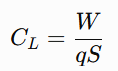

So;

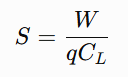

In [11]:
# ============================================================
# CRUISE CL CONSTRAINT
# ============================================================

cruise_constraint = {
    # Initial engineering target
    "target_CL_cruise": 0.50,

    "origin": "Engineering Assumption",
}

cruise_constraint

{'target_CL_cruise': 0.5, 'origin': 'Engineering Assumption'}

**ISA ATMOSPHERE**

In [12]:
# ============================================================
# ISA ATMOSPHERE
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Valid for the conceptual cruise-altitude range
    used in this notebook.
    """

    T0 = 288.15
    P0 = 101325.0

    lapse_rate = 0.0065

    R = 287.05
    g = 9.80665

    T = T0 - lapse_rate * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * lapse_rate)
    )

    rho = P / (R * T)

    return T, P, rho
    

**CRUISE ATMOSPHERE**

In [13]:
# ============================================================
# CRUISE ATMOSPHERE
# ============================================================

cruise_altitude_m = (
    requirements["cruise_altitude_ft"]
    * FT_TO_M
)

T_cruise, P_cruise, rho_cruise = (
    isa_atmosphere(
        cruise_altitude_m
    )
)

print(f"Temperature : {T_cruise:.2f} K")
print(f"Pressure    : {P_cruise:.1f} Pa")
print(f"Density     : {rho_cruise:.4f} kg/m³")

Temperature : 238.62 K
Pressure    : 37600.5 Pa
Density     : 0.5489 kg/m³


**CRUISE DYNAMIC PRESSURE**

In [15]:
# ============================================================
# CRUISE DYNAMIC PRESSURE
# ============================================================

V_cruise_ms = (
    requirements["cruise_speed_kt"]
    * KT_TO_MS
)

q_cruise = (
    0.5
    * rho_cruise
    * V_cruise_ms**2
)

print(
    f"Cruise speed = {V_cruise_ms:.2f} m/s"
)

print(
    f"Dynamic pressure = {q_cruise:.1f} Pa"
)

Cruise speed = 154.33 m/s
Dynamic pressure = 6537.6 Pa


**WING AREA FROM CRUISE CL**

In [16]:
# ============================================================
# WING AREA FROM CRUISE CL
# ============================================================

CL_cruise_target = (
    cruise_constraint["target_CL_cruise"]
)

wing_area_cruise_m2 = (
    MTOW_N
    / (
        q_cruise
        * CL_cruise_target
    )
)

print(
    f"Wing area from cruise CL = "
    f"{wing_area_cruise_m2:.2f} m²"
)

Wing area from cruise CL = 5.07 m²


**CONSTRAINT COMPARISON**

**WING AREA CONSTRAINT**

In [17]:
# ============================================================
# WING AREA CONSTRAINT COMPARISON
# ============================================================

constraint_table = pd.DataFrame({
    "Constraint": [
        "Benchmark-informed",
        "Stall speed",
        "Cruise CL",
    ],

    "Wing Area (m²)": [
        initial_wing_area_m2,
        wing_area_stall_m2,
        wing_area_cruise_m2,
    ],

    "Origin": [
        "Benchmark",
        "Physics + Engineering Assumption",
        "Physics + Engineering Assumption",
    ],
})

constraint_table

,Constraint,Wing Area (m²),Origin
0,Benchmark-informed,18.000000,Benchmark
1,Stall speed,13.435963,Physics + Engineering Assumption
2,Cruise CL,5.067131,Physics + Engineering Assumption


**PRELIMINARY WING AREA SELECTION**

In [18]:
# ============================================================
# PRELIMINARY WING AREA SELECTION
# ============================================================

wing_area_m2 = max(
    wing_area_stall_m2,
    wing_area_cruise_m2
)

print(
    f"Selected preliminary wing area = "
    f"{wing_area_m2:.2f} m²"
)

Selected preliminary wing area = 13.44 m²


**FINAL PRELIMINARY WING LOADING**

In [19]:
# ============================================================
# FINAL PRELIMINARY WING LOADING
# ============================================================

wing_loading_kg_m2 = (
    MTOW_kg
    / wing_area_m2
)

wing_loading_N_m2 = (
    MTOW_N
    / wing_area_m2
)

print(
    f"Wing loading = "
    f"{wing_loading_kg_m2:.2f} kg/m²"
)

print(
    f"Wing loading = "
    f"{wing_loading_N_m2:.2f} N/m²"
)

Wing loading = 125.71 kg/m²
Wing loading = 1232.77 N/m²


**ASPECT RATIO**

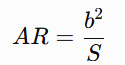

So;

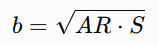

**ASPECT RATIO ASSUMPTION**

In [21]:
# ============================================================
# ASPECT RATIO
# ============================================================
#
# Initial benchmark-informed value.
#
# Later:
# - benchmark distribution
# - Raymer geometry guidance
# - structural considerations
# - induced drag
# - manufacturing constraints
#
# will influence this value.
# ============================================================

aspect_ratio = 9.15

aspect_ratio_origin = (
    "Benchmark-informed Engineering Assumption"
)

print(
    f"Aspect Ratio = {aspect_ratio:.2f}"
)

print(
    f"Origin = {aspect_ratio_origin}"
)

Aspect Ratio = 9.15
Origin = Benchmark-informed Engineering Assumption


**WING SPAN**

In [22]:
# ============================================================
# WING SPAN
# ============================================================

wing_span_m = np.sqrt(
    aspect_ratio
    * wing_area_m2
)

print(
    f"Wing span = {wing_span_m:.2f} m"
)

Wing span = 11.09 m


**MEAN AERODYNAMIC CHORD**

Basit rectangular-wing first-order approximation:

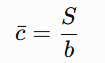

In [23]:
# ============================================================
# MEAN AERODYNAMIC CHORD
# ============================================================

mean_chord_m = (
    wing_area_m2
    / wing_span_m
)

print(
    f"Mean aerodynamic chord = "
    f"{mean_chord_m:.2f} m"
)

Mean aerodynamic chord = 1.21 m


**TAPER RATIO**

taper ratio = tip chord / root chord

**TAPER ASSUMPTION**

In [24]:
# ============================================================
# WING TAPER
# ============================================================

taper_ratio = 0.45

print(
    f"Taper ratio = {taper_ratio:.2f}"
)

print(
    "Origin = Engineering Assumption"
)

Taper ratio = 0.45
Origin = Engineering Assumption


**ROOT & TIP CHORD**

Trapezoidal wing:

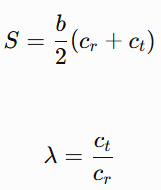

So that;

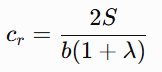

**ROOT AND TIP CHORD**

In [25]:
# ============================================================
# ROOT AND TIP CHORD
# ============================================================

root_chord_m = (
    2 * wing_area_m2
    / (
        wing_span_m
        * (1 + taper_ratio)
    )
)

tip_chord_m = (
    taper_ratio
    * root_chord_m
)

print(
    f"Root chord = {root_chord_m:.3f} m"
)

print(
    f"Tip chord  = {tip_chord_m:.3f} m"
)

Root chord = 1.671 m
Tip chord  = 0.752 m


**GEOMETRY CHECK**

In [26]:
# ============================================================
# GEOMETRY CLOSURE CHECK
# ============================================================

area_reconstructed_m2 = (
    wing_span_m
    * (
        root_chord_m
        + tip_chord_m
    )
    / 2
)

geometry_error = (
    area_reconstructed_m2
    - wing_area_m2
)

print(
    f"Target wing area        : "
    f"{wing_area_m2:.6f} m²"
)

print(
    f"Reconstructed wing area : "
    f"{area_reconstructed_m2:.6f} m²"
)

print(
    f"Geometry closure error  : "
    f"{geometry_error:.6e} m²"
)

Target wing area        : 13.435963 m²
Reconstructed wing area : 13.435963 m²
Geometry closure error  : 0.000000e+00 m²


**WING GEOMETRY SUMMARY**

In [27]:
# ============================================================
# PRELIMINARY WING GEOMETRY
# ============================================================

wing_geometry = pd.Series({
    "MTOW_kg": MTOW_kg,

    "Wing_Area_m2": wing_area_m2,

    "Wing_Loading_kg_m2":
        wing_loading_kg_m2,

    "Wing_Loading_N_m2":
        wing_loading_N_m2,

    "Aspect_Ratio":
        aspect_ratio,

    "Wing_Span_m":
        wing_span_m,

    "Mean_Chord_m":
        mean_chord_m,

    "Root_Chord_m":
        root_chord_m,

    "Tip_Chord_m":
        tip_chord_m,

    "Taper_Ratio":
        taper_ratio,
})

wing_geometry

MTOW_kg               1689.000000
Wing_Area_m2            13.435963
Wing_Loading_kg_m2     125.707401
Wing_Loading_N_m2     1232.768487
Aspect_Ratio             9.150000
Wing_Span_m             11.087789
Mean_Chord_m             1.211780
Root_Chord_m             1.671421
Tip_Chord_m              0.752139
Taper_Ratio              0.450000
dtype: float64

**WING PLANFORM VISUALIZATION**

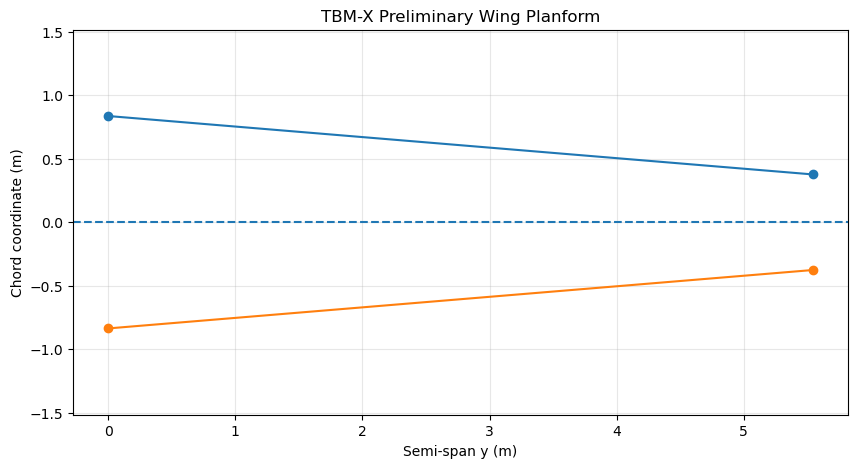

In [28]:
# ============================================================
# WING PLANFORM
# ============================================================

half_span = wing_span_m / 2

y = np.array([
    0,
    half_span
])

chord = np.array([
    root_chord_m,
    tip_chord_m
])

plt.figure(figsize=(10, 5))

plt.plot(
    y,
    chord / 2,
    marker="o"
)

plt.plot(
    y,
    -chord / 2,
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Semi-span y (m)")
plt.ylabel("Chord coordinate (m)")
plt.title("TBM-X Preliminary Wing Planform")

plt.grid(True, alpha=0.3)

plt.axis("equal")

plt.show()

**WING LOADING SENSITIVITY**

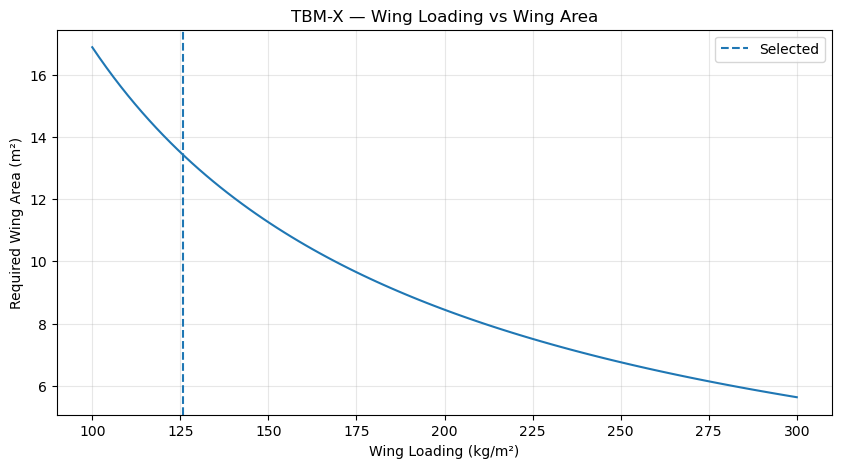

In [29]:
# ============================================================
# WING LOADING SENSITIVITY
# ============================================================

wing_loading_range = np.linspace(
    100,
    300,
    100
)

required_area = (
    MTOW_kg
    / wing_loading_range
)

plt.figure(figsize=(10, 5))

plt.plot(
    wing_loading_range,
    required_area
)

plt.axvline(
    wing_loading_kg_m2,
    linestyle="--",
    label="Selected"
)

plt.xlabel("Wing Loading (kg/m²)")
plt.ylabel("Required Wing Area (m²)")
plt.title("TBM-X — Wing Loading vs Wing Area")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**ASPECT RATIO SENSITIVITY**

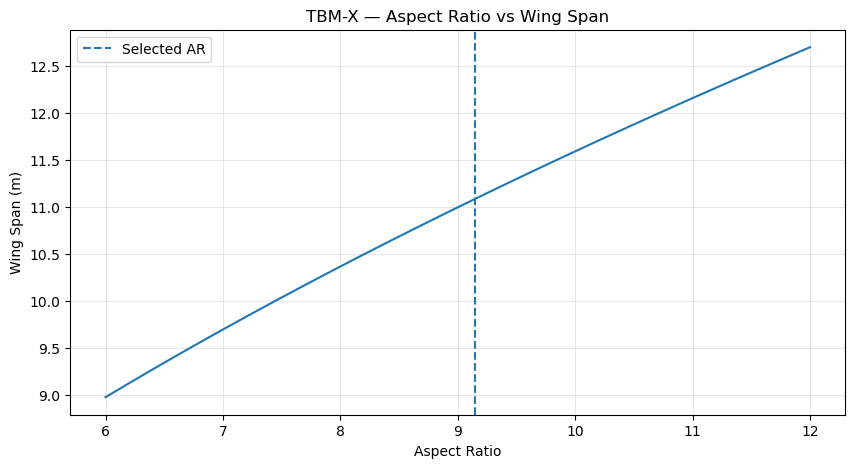

In [30]:
# ============================================================
# ASPECT RATIO SENSITIVITY
# ============================================================

AR_range = np.linspace(
    6,
    12,
    100
)

span_range = np.sqrt(
    AR_range
    * wing_area_m2
)

plt.figure(figsize=(10, 5))

plt.plot(
    AR_range,
    span_range
)

plt.axvline(
    aspect_ratio,
    linestyle="--",
    label="Selected AR"
)

plt.xlabel("Aspect Ratio")
plt.ylabel("Wing Span (m)")
plt.title("TBM-X — Aspect Ratio vs Wing Span")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**STALL SPEED VALIDATION**

In [31]:
# ============================================================
# STALL SPEED VALIDATION
# ============================================================

Vs_check_ms = np.sqrt(
    (
        2 * MTOW_N
    )
    / (
        rho_sl
        * wing_area_m2
        * CLmax_landing
    )
)

Vs_check_kt = (
    Vs_check_ms
    / KT_TO_MS
)

print(
    f"Target stall speed : "
    f"{requirements['stall_speed_landing_kt']:.2f} kt"
)

print(
    f"Calculated stall speed : "
    f"{Vs_check_kt:.2f} kt"
)

print(
    f"Difference : "
    f"{Vs_check_kt - requirements['stall_speed_landing_kt']:.2f} kt"
)

Target stall speed : 65.00 kt
Calculated stall speed : 65.00 kt
Difference : 0.00 kt


**CRUISE CL VALIDATION**

In [32]:
# ============================================================
# CRUISE CL VALIDATION
# ============================================================

CL_cruise = (
    MTOW_N
    / (
        q_cruise
        * wing_area_m2
    )
)

print(
    f"Cruise CL = {CL_cruise:.4f}"
)

print(
    f"Target CL  = {CL_cruise_target:.4f}"
)

Cruise CL = 0.1886
Target CL  = 0.5000


**BENCHMARK COMPARISON**

In [33]:
# ============================================================
# LOAD BENCHMARK DATA
# ============================================================

benchmark_candidates = [
    current_dir / "../03_benchmark_database/TBM_X_Master_v0_2.csv",
    current_dir / "../data/processed/TBM_X_Master_v0_2.csv",
    current_dir / "data/processed/TBM_X_Master_v0_2.csv",
]

benchmark_path = None

for candidate in benchmark_candidates:

    candidate = candidate.resolve()

    if candidate.exists():
        benchmark_path = candidate
        break

if benchmark_path is not None:

    benchmark_df = pd.read_csv(
        benchmark_path
    )

    print(
        "Benchmark loaded from:"
    )

    print(
        benchmark_path
    )

else:

    benchmark_df = None

    print(
        "Benchmark file not found."
    )

Benchmark loaded from:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\processed\TBM_X_Master_v0_2.csv


**TBM GEOMETRY BENCHMARK**

In [34]:
# ============================================================
# TBM BENCHMARK GEOMETRY
# ============================================================

if benchmark_df is not None:

    tbm_benchmark = benchmark_df[
        benchmark_df["aircraft_id"].str.contains(
            "TBM",
            case=False,
            na=False
        )
    ].copy()

    geometry_columns = [
        "aircraft_id",
        "MTOW_kg",
        "wing_area_m2",
        "span_m",
    ]

    available_columns = [
        col
        for col in geometry_columns
        if col in tbm_benchmark.columns
    ]

    display(
        tbm_benchmark[
            available_columns
        ]
    )

,aircraft_id,MTOW_kg,wing_area_m2,span_m
0,TBM960,3454.000000,18.0,12.83000
1,TBM910,3353.861984,NaN,12.83208
2,TBM940,3354.000000,NaN,NaN


**TBM-X vs BENCHMARK**

***BENCHMARK-AS-CHECK***

In [35]:
# ============================================================
# ENGINEERING VALIDATION
# ============================================================

print("==============================================")
print("TBM-X GEOMETRY VALIDATION")
print("==============================================")

print(
    f"MTOW              : {MTOW_kg:.1f} kg"
)

print(
    f"Wing area         : {wing_area_m2:.2f} m²"
)

print(
    f"Wing span         : {wing_span_m:.2f} m"
)

print(
    f"Aspect ratio      : {aspect_ratio:.2f}"
)

print(
    f"Wing loading      : {wing_loading_kg_m2:.2f} kg/m²"
)

print(
    f"Calculated Vs     : {Vs_check_kt:.2f} kt"
)

print(
    f"Cruise CL         : {CL_cruise:.3f}"
)

print("==============================================")
print("Benchmark is used for validation,")
print("not for forcing the TBM-X design.")
print("==============================================")

TBM-X GEOMETRY VALIDATION
MTOW              : 1689.0 kg
Wing area         : 13.44 m²
Wing span         : 11.09 m
Aspect ratio      : 9.15
Wing loading      : 125.71 kg/m²
Calculated Vs     : 65.00 kt
Cruise CL         : 0.189
Benchmark is used for validation,
not for forcing the TBM-X design.


**FINAL GEOMETRY DATASET ROW**

In [36]:
# ============================================================
# TBM-X GEOMETRY DESIGN VECTOR
# ============================================================

design_vector = pd.DataFrame([{
    "MTOW_kg": MTOW_kg,

    "wing_area_m2":
        wing_area_m2,

    "wing_loading_kg_m2":
        wing_loading_kg_m2,

    "aspect_ratio":
        aspect_ratio,

    "wing_span_m":
        wing_span_m,

    "mean_chord_m":
        mean_chord_m,

    "root_chord_m":
        root_chord_m,

    "tip_chord_m":
        tip_chord_m,

    "taper_ratio":
        taper_ratio,

    "CL_cruise":
        CL_cruise,

    "CLmax_landing":
        CLmax_landing,

    "stall_speed_kt":
        Vs_check_kt,
}])

design_vector


,MTOW_kg,wing_area_m2,wing_loading_kg_m2,aspect_ratio,wing_span_m,mean_chord_m,root_chord_m,tip_chord_m,taper_ratio,CL_cruise,CLmax_landing,stall_speed_kt
0,1689.0,13.435963,125.707401,9.15,11.087789,1.21178,1.671421,0.752139,0.45,0.188566,1.8,65.0


**SAVE GEOMETRY RESULTS**

In [37]:
# ============================================================
# SAVE GEOMETRY RESULTS
# ============================================================

output_dir = current_dir / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

geometry_output_path = (
    output_dir
    / "TBM_X_geometry_sizing.csv"
)

design_vector.to_csv(
    geometry_output_path,
    index=False
)

print(
    "Geometry results saved to:"
)

print(
    geometry_output_path.resolve()
)

Geometry results saved to:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\TBM_X_geometry_sizing.csv


**FINAL SUMMARY**

In [38]:
# ============================================================
# FINAL ENGINEERING SUMMARY
# ============================================================

print("""
============================================================
TBM-X — RAYMER GEOMETRY SIZING
============================================================

DESIGN INPUT
------------
MTOW
Cruise speed
Cruise altitude
Landing stall speed

CONSTRAINTS
-----------
Stall speed
Cruise CL
Wing loading

GEOMETRY
--------
Wing area
Wing span
Aspect ratio
Mean aerodynamic chord
Root chord
Tip chord
Taper ratio

VALIDATION
----------
Stall speed check
Cruise CL check
Benchmark comparison
Geometry closure check

IMPORTANT
---------
The resulting geometry is preliminary conceptual sizing.

Benchmark data is used for validation,
not to force the TBM-X design toward an existing aircraft.

NEXT STEP
---------
07 — RAYMER / PHYSICS-BASED AERODYNAMIC MODEL

============================================================
""")


TBM-X — RAYMER GEOMETRY SIZING

DESIGN INPUT
------------
MTOW
Cruise speed
Cruise altitude
Landing stall speed

CONSTRAINTS
-----------
Stall speed
Cruise CL
Wing loading

GEOMETRY
--------
Wing area
Wing span
Aspect ratio
Mean aerodynamic chord
Root chord
Tip chord
Taper ratio

VALIDATION
----------
Stall speed check
Cruise CL check
Benchmark comparison
Geometry closure check

IMPORTANT
---------
The resulting geometry is preliminary conceptual sizing.

Benchmark data is used for validation,
not to force the TBM-X design toward an existing aircraft.

NEXT STEP
---------
07 — RAYMER / PHYSICS-BASED AERODYNAMIC MODEL


